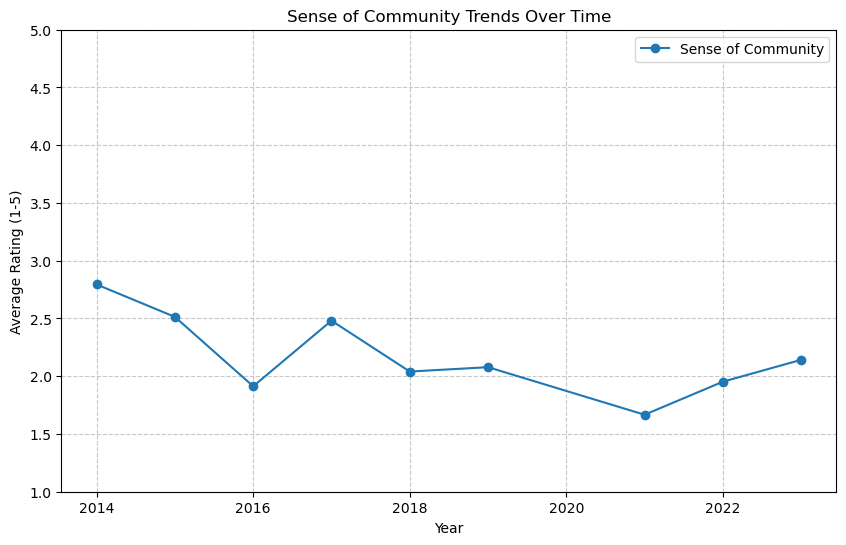


--- Correlation: How Community relates to other pillars ---
Category
Community           1.000000
Academics           0.435451
Support Services    0.418726
Other               0.176599
Housing            -0.451624
Name: Community, dtype: float64


/var/folders/vq/65_jc29x4t99fzflrw6qrdsr0000gn/T/ipykernel_5122/2900139235.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_scores, x='Recommend_Rating', y='Community_Rating', palette="light:b")


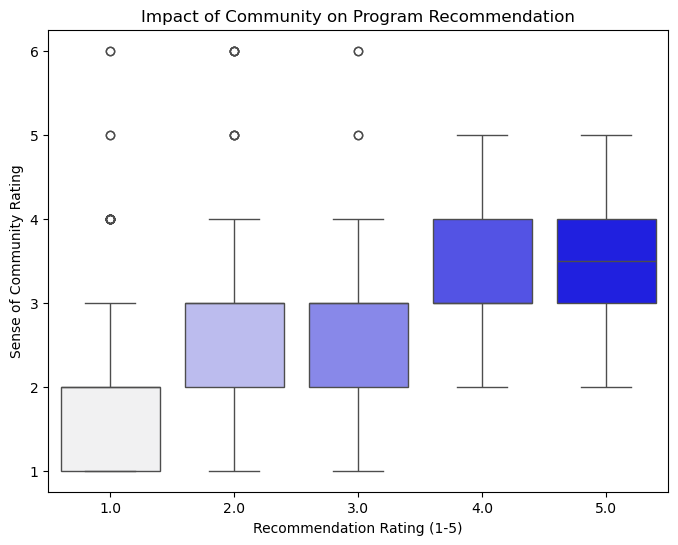

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP & DATA LOADING

# Use low_memory=False to handle the mixed-type columns in your dataset
file_path = "/Users/hallewhitman/Downloads/sa_exit_MASTER_merged_all4 2.csv" #update dataset path
df = pd.read_csv(file_path, low_memory=False)

# Ensure 'Year' is numeric and sort it for chronological plotting
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year']).sort_values('Year')

# 2. PREPARATION & CLEANING

# Convert 'Year' to numeric to ensure the charts sort chronologically
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Extract numeric Likert scores from text (e.g., "(4) Agree" -> 4.0)
# This uses your original regex logic from the notebook
df["LikertScore"] = df["ResponseText"].str.extract(r'\((\d)\)').astype(float)

# 3. CATEGORIZATION LOGIC

def categorize_question(text):
    """Categorizes survey questions based on your original notebook keywords."""
    text = str(text).lower()
    if "community" in text or "belong" in text:
        return "Community"
    elif "academic" in text or "class" in text or "course" in text:
        return "Academics"
    elif "support" in text or "staff" in text or "advising" in text:
        return "Support Services"
    elif "housing" in text or "dorm" in text:
        return "Housing"
    else:
        return "Other"

# Apply categories to the QuestionText
df["Category"] = df["QuestionText"].apply(categorize_question)

# 4. TREND ANALYSIS (Scalable for New Years)
# Filter for Likert responses only to calculate averages
likert_df = df[df["ResponseType"] == "Likert"].copy()

# Group by Year and Category - this automatically scales as you add 2026, 2027, etc.
year_category_avg = likert_df.groupby(["Year", "Category"])["LikertScore"].mean().reset_index()

# Plot the "Community" trend over time
plt.figure(figsize=(10, 6))
community_data = year_category_avg[year_category_avg["Category"] == "Community"]
plt.plot(community_data["Year"], community_data["LikertScore"], marker='o', label='Sense of Community', color='#1f77b4')

plt.title("Sense of Community Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rating (1-5)")
plt.ylim(1, 5) # Keeps the scale consistent for year-over-year comparison
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 5. CORRELATION ANALYSIS (REPLICATING YOUR INSIGHTS)
# Pivot the data so categories are columns for correlation math
pivot_df = year_category_avg.pivot(index="Year", columns="Category", values="LikertScore")

print("\n--- Correlation: How Community relates to other pillars ---")
# This calculates the 'r' values to see if Academics or Support drive belonging
if "Community" in pivot_df.columns:
    correlations = pivot_df.corr()["Community"].sort_values(ascending=False)
    print(correlations)

# 6. SATISFACTION INSIGHTS (Boxplot)
# Connect students who would recommend the program to their Community rating
rec_q = "Overall, I would recommend ACT for a Study Abroad program."
recommend = df[df["QuestionText"].str.contains("recommend", case=False, na=False)][["ResponseID", "LikertScore"]]
recommend = recommend.rename(columns={"LikertScore": "Recommend_Rating"})

community_scores = df[df["Category"] == "Community"][["ResponseID", "LikertScore"]]
community_scores = community_scores.rename(columns={"LikertScore": "Community_Rating"})

# Merge per student to create the boxplot insight
merged_scores = pd.merge(recommend, community_scores, on="ResponseID").dropna()

plt.figure(figsize=(8, 6))
sns.boxplot(data=merged_scores, x='Recommend_Rating', y='Community_Rating', palette="light:b")
plt.title("Impact of Community on Program Recommendation")
plt.xlabel("Recommendation Rating (1-5)")
plt.ylabel("Sense of Community Rating")
plt.show()